In [176]:
import pandas as pd
import matplotlib.pyplot as plt

In [177]:
df = pd.read_csv("dataset/vampire-2026-07-13.csv")
df

,file,option_set,status,cpu_time,Solve time,Repair time,Add clause,Decisions,Conflict repair,Implication,...,Backtrack forced chunks,Backtrack better chunks,Failed learning,Allocated Chunk,Avg number of backtrack choices,Backward subsumption,Cost %s4imatinn time,Repair tIme,Restart,Backtrack limit reached
0,AGT005+1.p,cb,true,21.12,1883.0,245.0,480226.0,5789938.0,1077.0,665719.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGT005+1.p,gb,true,29.28,6486.0,15177.0,774806.0,14535.0,2918.0,12514.0,...,2890.0,14.0,2.0,16128.0,3.94,NaN,NaN,NaN,NaN,NaN
2,AGT005+1.p,minisat,true,20.04,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGT005+1.p,ncb,TIMEOUT,59.51,32451.0,905.0,772453.0,69119334.0,1388.0,14776013.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGT006+1.p,cb,TIMEOUT,59.47,2387.0,364.0,521076.0,8230649.0,1674.0,1247400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79895,TOP048+3.p,ncb,TIMEOUT,60.07,20559.0,1260.0,53060.0,35969026.0,720.0,17133065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79896,TOP048+4.p,cb,TIMEOUT,60.09,4736.0,665.0,156237.0,7373323.0,598.0,4764480.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79897,TOP048+4.p,gb,TIMEOUT,59.79,26737.0,32271.0,83922.0,54777.0,651.0,60309.0,...,650.0,NaN,NaN,64512.0,4.95,NaN,NaN,NaN,NaN,NaN
79898,TOP048+4.p,minisat,TIMEOUT,60.06,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [178]:
solved = df[(df["status"] == "true") | (df["status"] == "false")]

options = solved["option_set"].unique()

solved_by_all = solved.groupby("file").filter(lambda x: set(x["option_set"]) == set(options))["file"].unique()

print("Problems solved by minisat:", solved[solved["option_set"] == "minisat"].shape[0])
print("Problems solved by ncb:", solved[solved["option_set"] == "ncb"].shape[0])
print("Problems solved by cb:", solved[solved["option_set"] == "cb"].shape[0])
print("Problems solved by all options: ", solved_by_all.shape[0])

Problems solved by minisat: 9628
Problems solved by ncb: 9380
Problems solved by cb: 9522
Problems solved by all options:  8865


In [179]:
# save to a file the name of all problems that use splitting
using_splitting = df.groupby("file").filter(lambda x: x["Add clause"].notna().any())["file"].unique()
no_using_splitting = df.groupby("file").filter(lambda x: x["Add clause"].isna().all())["file"].unique()

using_splitting = sorted(using_splitting)
no_using_splitting = sorted(no_using_splitting)

print("Problems using splitting: ", len(using_splitting))
print("Problems not using splitting: ", len(no_using_splitting))
print("Total problems: ", len(df["file"].unique()))

# interesting problems have more than 500 clauses added to the SAT solver.
interesting_problems = df.groupby("file").filter(lambda x: x["Add clause"].max() >= 500)["file"].unique()

print("Interesting problems: ", len(interesting_problems))

# with open("interesting.txt", "w") as f:
#     for problem in interesting_problems:
#         f.write("    <include>/data/benchmarks/TPTP-v9.2.1/Problems/" + problem[0:3] + "/" + problem + "</include>\n")

Problems using splitting:  18793
Problems not using splitting:  1182
Total problems:  19975
Interesting problems:  10669


In [180]:
# extract the problems where "Add clause" is Nan for all options
problems_not_using_splitting = solved.groupby("file").filter(lambda x: x["Add clause"].isna().all())["file"].unique()
print("Problems not using splitting: ", problems_not_using_splitting.shape[0])

# remove those problems from the solved dataframe
solved = solved[~solved["file"].isin(problems_not_using_splitting)]

# remove problem with trivial SAT part. That is, problems where no solution got more than 1000 clauses
solved = solved[solved.groupby("file")["Add clause"].transform("max") >= 500]

Problems not using splitting:  732


Problems solved by both minisat and ncb:  2048
Problems solved by minisat only:  409
Problems solved by ncb only:  266


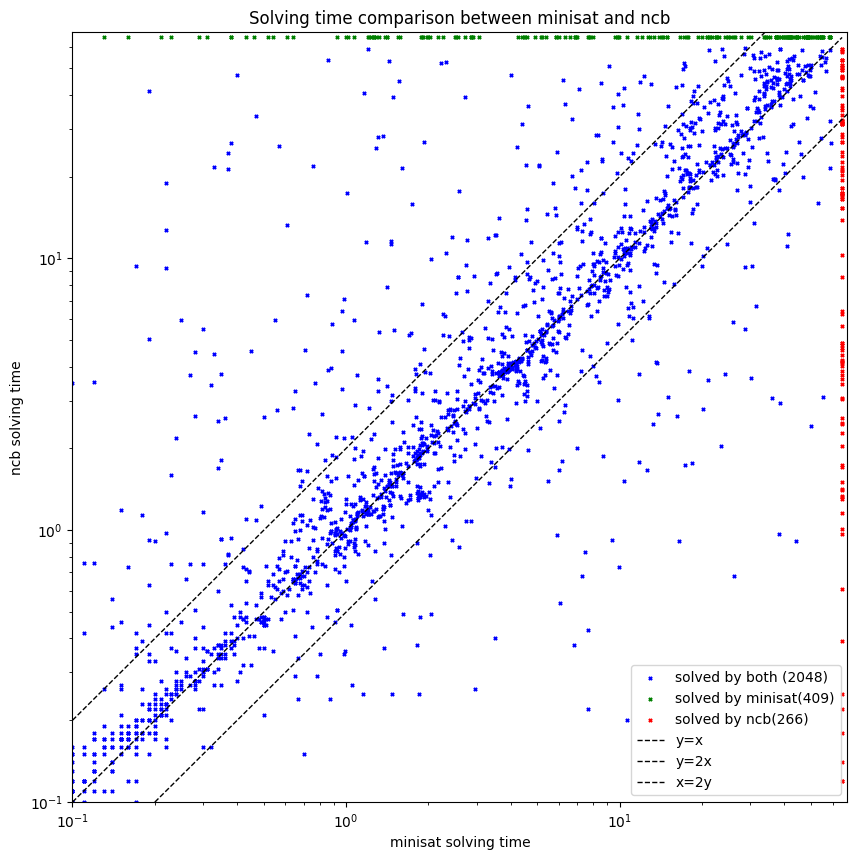

Problems solved by both minisat and cb:  2153
Problems solved by minisat only:  158
Problems solved by cb only:  313


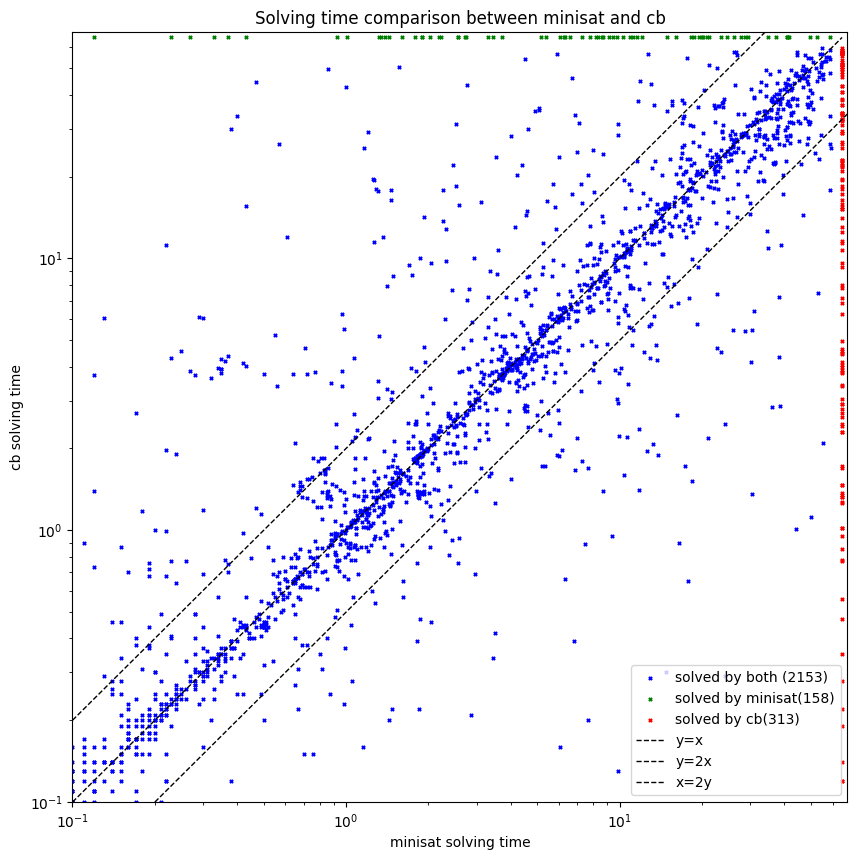

Problems solved by both ncb and cb:  2080
Problems solved by ncb only:  149
Problems solved by cb only:  447


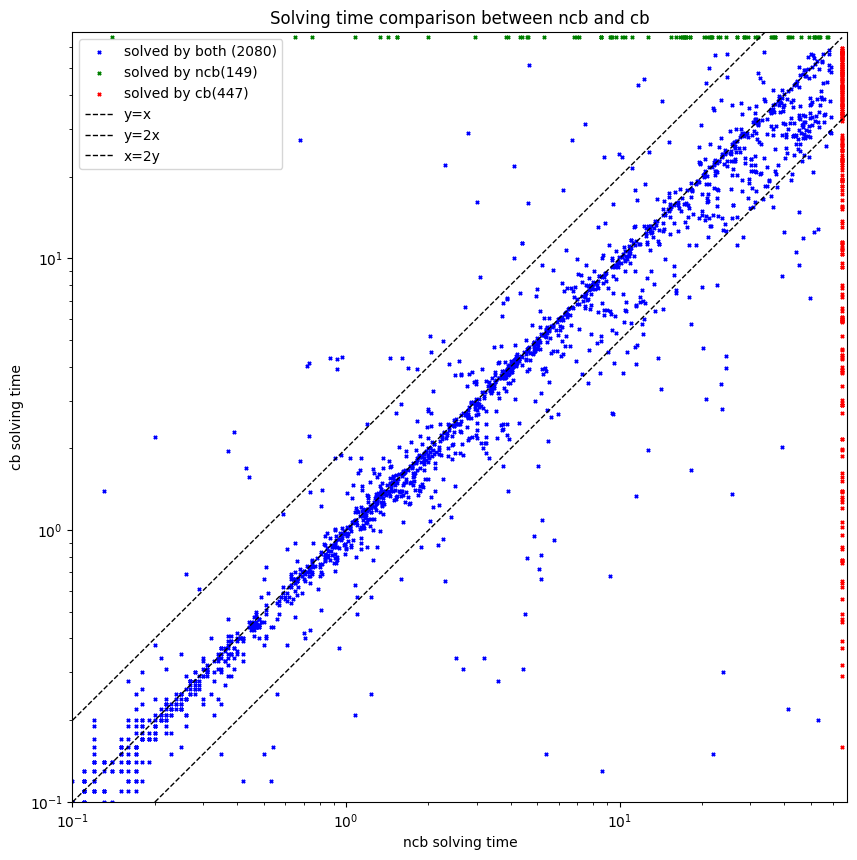

Problems solved by both ncb and gb:  1903
Problems solved by ncb only:  673
Problems solved by gb only:  286


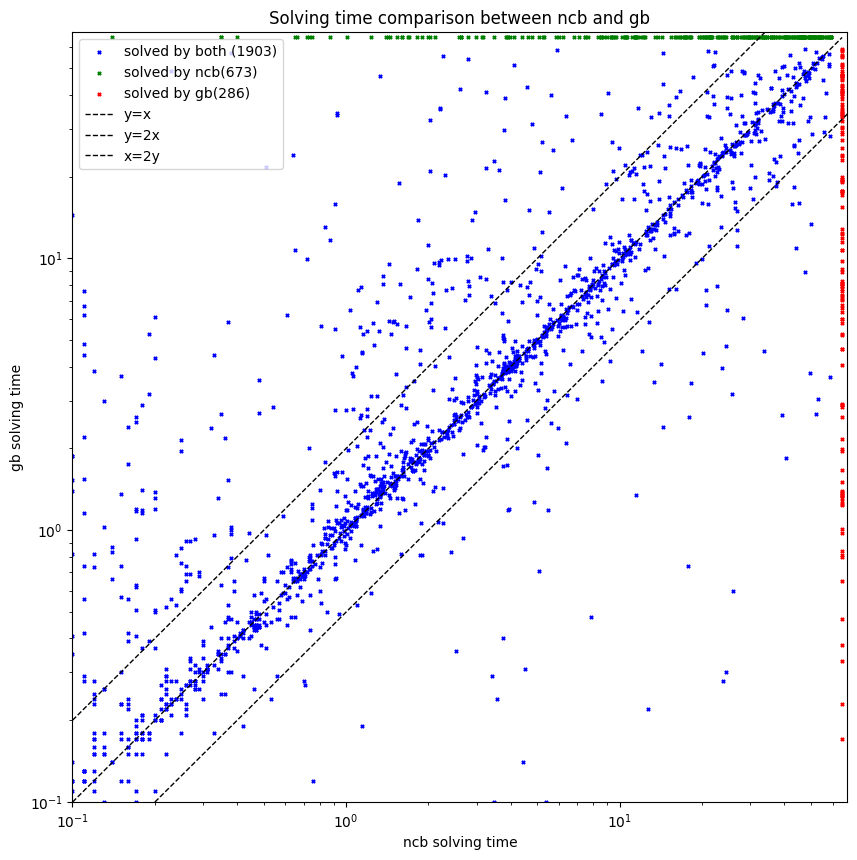

Problems solved by both cb and gb:  1966
Problems solved by cb only:  804
Problems solved by gb only:  119


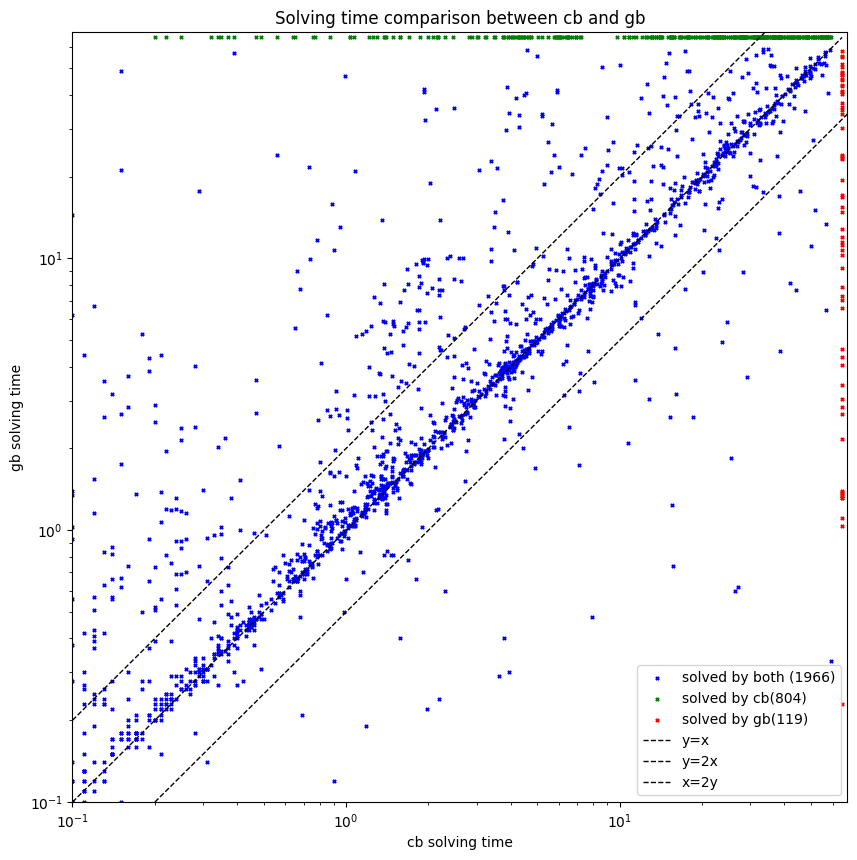

In [181]:
# create a scatter plot of the solving time for each option set

for pair in [["minisat", "ncb"], ["minisat", "cb"], ["ncb", "cb"], ["ncb", "gb"], ["cb", "gb"]]:
    plt.figure(figsize=(10, 10))

    # first plot the points that are solved by both options
    solved_by_both = solved.groupby("file").filter(lambda x: set(x["option_set"]) >= set(pair))["file"].unique()

    plt.scatter(
        solved[(solved["file"].isin(solved_by_both)) & (solved["option_set"] == pair[0])]["cpu_time"],
        solved[(solved["file"].isin(solved_by_both)) & (solved["option_set"] == pair[1])]["cpu_time"],
        label="solved by both (" + str(solved_by_both.shape[0]) + ")",
        color="blue",
        s=5,
        marker="x"
    )
    print("Problems solved by both " + pair[0] + " and " + pair[1] + ": ", solved_by_both.shape[0])

    # then plot the points that are solved by only one of the options with cpu time set to 65 for the other option
    solved_by_first = solved.groupby("file").filter(lambda x: pair[0] in set(x["option_set"]) and pair[1] not in set(x["option_set"]))
    print("Problems solved by " + pair[0] + " only: ", solved_by_first.shape[0])

    plt.scatter(
        solved_by_first[solved_by_first["option_set"] == pair[0]]["cpu_time"],
        [65] * solved_by_first[solved_by_first["option_set"] == pair[0]].shape[0],
        label="solved by " + pair[0] + "(" + str(solved_by_first.shape[0]) + ")",
        color="green",
        s=5,
        marker="x"
    )

    solved_by_second = solved.groupby("file").filter(lambda x: pair[1] in set(x["option_set"]) and pair[0] not in set(x["option_set"]))

    print("Problems solved by " + pair[1] + " only: ", solved_by_second.shape[0])

    plt.scatter(
        [65] * solved_by_second[solved_by_second["option_set"] == pair[1]].shape[0],
        solved_by_second[solved_by_second["option_set"] == pair[1]]["cpu_time"],
        label="solved by " + pair[1] + "(" + str(solved_by_second.shape[0]) + ")",
        color="red",
        s=5,
        marker="x",
    )

    # plot the line y=x to show where the solving times are equal
    plt.plot([0.1, 65], [0.1, 65], color="black", linestyle="--", linewidth=1, label="y=x")
    # plot x = 2y and y = 2x to show where the solving times differ by a factor of 2
    plt.plot([0.1, 65], [0.2, 130], color="black", linestyle="--", linewidth=1, label="y=2x")
    plt.plot([0.2, 130], [0.1, 65], color="black", linestyle="--", linewidth=1, label="x=2y")


    plt.xlabel(pair[0] + " solving time")
    plt.ylabel(pair[1] + " solving time")
    plt.title("Solving time comparison between " + pair[0] + " and " + pair[1])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(0.1, 68)
    plt.ylim(0.1, 68)
    plt.legend()
    plt.show()


In [182]:
solved["ratio"] = solved["Solve time"] /1000 / solved["cpu_time"]
solved[['file', 'option_set', 'cpu_time', 'Solve time', 'ratio']]

solved = solved.sort_values(by="ratio", ascending=False)
solved[["file", "option_set", "cpu_time", "Solve time", "ratio", "Add clause"]].head(20)

,file,option_set,cpu_time,Solve time,ratio,Add clause
61073,SWC181+1.p,gb,0.12,298.0,2.483333,833.0
829,ALG141+1.p,gb,0.18,312.0,1.733333,1337.0
505,ALG060+1.p,gb,0.70,1184.0,1.691429,1116.0
46185,SET007-1.p,gb,0.81,1322.0,1.632099,1137.0
685,ALG105+1.p,gb,0.51,664.0,1.301961,2468.0
46368,SET018-6.p,cb,0.12,152.0,1.266667,414.0
1485,ALG254^2.p,gb,0.25,298.0,1.192000,1491.0
665,ALG100+1.p,gb,1.38,1626.0,1.178261,4265.0
1521,ALG259^2.p,gb,0.28,325.0,1.160714,1536.0
417,ALG038+1.p,gb,0.59,619.0,1.049153,1351.0


Note: no per-solver 'Solve time' stat is logged for: minisat -- excluded from the plot.


/tmp/ipykernel_49227/2952696862.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


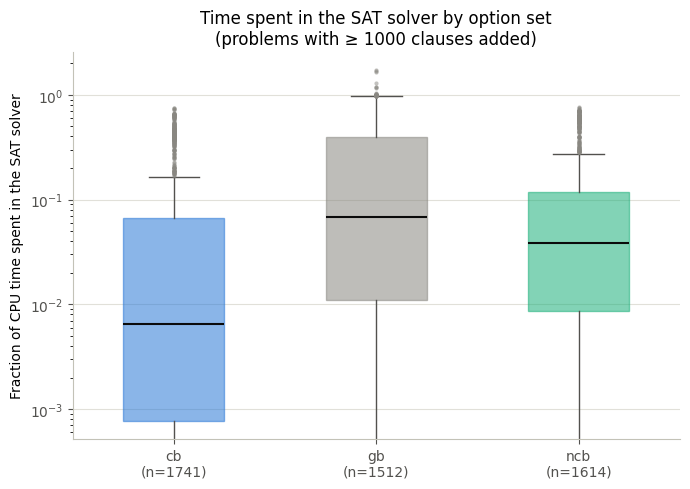

In [183]:
# create a box plot of the time spent in the SAT solver ratio for each option set
# only keep problems that made substantial use of the SAT solver (enough
# clauses added), otherwise trivial/fast problems flood the plot with zeros
substantial = solved[solved["Add clause"] >= 1000]

ratio_by_option = {
    option: substantial.loc[substantial["option_set"] == option, "ratio"].dropna()
    for option in options
}
ratio_by_option = {option: values for option, values in ratio_by_option.items() if len(values) > 0}

# fixed categorical colors, one per option set
palette = {
    "cb": "#2a78d6",       # blue
    "ncb": "#1baf7a",      # aqua
    "minisat": "#eda100",  # yellow
}
labels = list(ratio_by_option.keys())
colors = [palette.get(label, "#898781") for label in labels]

fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot(
    [ratio_by_option[label] for label in labels],
    labels=[f"{label}\n(n={len(ratio_by_option[label])})" for label in labels],
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    flierprops=dict(marker="o", markersize=3, markerfacecolor="#898781", markeredgecolor="none", alpha=0.5),
    medianprops=dict(color="#0b0b0b", linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(color="#52514e", linewidth=1),
    capprops=dict(color="#52514e", linewidth=1),
)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)

ax.set_ylabel("Fraction of CPU time spent in the SAT solver")
ax.set_title("Time spent in the SAT solver by option set\n(problems with ≥ 1000 clauses added)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e")

missing = [option for option in options if option not in ratio_by_option]
if missing:
    print(f"Note: no per-solver 'Solve time' stat is logged for: {', '.join(missing)} -- excluded from the plot.")

# set y-axis to log scale
ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [184]:
solved_by_option = {
    option: solved.loc[solved["option_set"] == option, "file"]
    for option in options
}


to_inspect = df[df["file"].isin(solved_by_option["cb"]) & ~df["file"].isin(solved_by_option["gb"])]

to_inspect = to_inspect.sort_values(by="file")
# to_inspect.to_csv("to_inspect.csv", index=False)